# Prediksi Huruf Arab Menggunakan Algoritma Desicion Tree Berdasarkan Data Latih Hasil Ekstraksi Gambar

Huruf arab/hijaiyah merupakan dasar sistem penulisan bahasa Arab yang terdiri dari berbagai karakter dengan bentuk yang berbeda.

### Tujuan:
1. Memahami pola dan informasi pada dataset
2. Mengembangkan model AI yang mampu mengklasifikasikan/membedakan huruf arab/hijaiah
3. Membangun aplikasi GUI sederhana yang mampu digunakan oleh pengguna untuk melakukan prediksi

----------

### Informasi Dataset 
Dataset mencakup sekitar 16.800 gambar huruf Arab tulisan tangan yang dikumpulkan dari berbagai penulis sehingga memiliki variasi bentuk tulisan yang cukup beragam. Setiap gambar dalam dataset telah diproses sehingga memiliki ukuran yang seragam yaitu 32 × 32 piksel. Data citra tersebut telah diubah menjadi bentuk fitur numerik (tabular) melalui proses ekstraksi fitur.

Kolom Yang Tersedia Pada Dataset:

H1 : merepresentasikan karakteristik dasar bentuk objek pada citra. Fitur ini bersifat invariant terhadap translasi, rotasi, dan skala.

H2 : menggambarkan variasi distribusi bentuk objek pada citra huruf.

H3 : menangkap informasi ketidaksimetrian bentuk karakter pada citra.

H4 : menggambarkan kompleksitas struktur bentuk huruf pada citra

H5 : merepresentasikan pola distribusi piksel yang lebih kompleks dari objek huruf.

H6 : menangkap variasi bentuk tambahan yang tidak terdeteksi oleh moment sebelumnya.

H7 : menggambarkan karakteristik bentuk yang lebih detail dari objek huruf pada citra.

label : Kelas huruf hijaiyah yang direpresentasikan oleh gambar. Nilai label menunjukkan kategori huruf Arab tertentu yang menjadi target klasifikasi.

----------------

# A. Exploratory Data Analysis

A.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tkinter import *
from tkinter import messagebox

A.2 Import Dataset

In [2]:
df = pd.read_csv('data.csv')
df.head()

,h1,h2,h3,h4,h5,h6,h7,label
0,2.514199,5.124566,7.911098,8.097373,10.000000,9.914997,10.0,1
1,2.456730,4.991479,8.206171,8.832098,10.000000,9.994664,-10.0,1
2,2.433630,4.935082,7.791826,7.991053,9.999999,9.871951,-10.0,1
3,2.535467,5.131711,8.187498,8.345384,10.000000,9.950814,-10.0,1
4,2.600422,5.332487,8.179446,8.444743,10.000000,9.968503,-10.0,1


A.3 Menampilkan Informasi Data

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16800 entries, 0 to 16799
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   h1      16800 non-null  float64
 1   h2      16800 non-null  float64
 2   h3      16800 non-null  float64
 3   h4      16800 non-null  float64
 4   h5      16800 non-null  float64
 5   h6      16800 non-null  float64
 6   h7      16800 non-null  float64
 7   label   16800 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 1.0 MB


Berdasarkan Informasi Tersebut:
- Data memiliki 16800 baris dan 8 Kolom
- Kolom Fitur memiliki tipe data float, sedangkan label memiliki tipe data integer

A.4 Menampilkan Statistik Deskripstif Data

In [133]:
df.describe()

,h1,h2,h3,h4,h5,h6,h7,label
count,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000
mean,2.656956,5.931459,8.724038,9.214610,2.815476,0.997950,-0.297619,14.500000
std,0.145339,0.621336,0.562211,0.497802,9.595137,9.942595,9.995272,8.077988
min,0.000000,0.000000,0.000000,0.000000,-10.000000,-10.000000,-10.000000,1.000000
25%,2.558385,5.515246,8.349731,8.911653,-10.000000,-9.999145,-10.000000,7.750000
50%,2.656765,5.857006,8.727641,9.272345,10.000000,9.976276,-10.000000,14.500000
75%,2.756526,6.268472,9.114345,9.593375,10.000000,9.998904,10.000000,21.250000
max,3.153870,9.589201,10.000000,10.000000,10.000000,10.000000,10.000000,28.000000


Berdasarkan Statistik Deskriptif Diatas :

1. Semua Kolom Tidak Memiliki Missing Value, bisa dibuktikan dengan count tiap kolom sama dengan yang ada di informasi data diatas
2. Kolom H1 - H4 Memiliki Standar deviasi yang mirip yaitu di angka 0.1-0.6, sedangkan H5-H7 mirip yaitu di angka 0.9-10.
3. Kolom h5-h7 memiliki Q1, Q2, dan Q3, yang mirip, ini bisa menandakan ada kemungkinan bahwa kolom kolom tersebut memiliki nilai di sekitar(-10) dan sekitar(10)

Namun ini masih harus dibuktikan dengan visualisasi lainya seperti histogram

A.5 Menampilkan Duplikasi Data

In [134]:
df.duplicated().sum()

np.int64(1)

Insight:
Terdapat satu data duplikat yang akan kami tangani dengan menghapusnya di data preparation

A.6 Menampilkan Nilai Unik Dari Kolom Label

In [135]:
df['label'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

Insight:

Huruf hijaiah/arab memiliki jumlah huruf dengan total 30 huruf, namun pada dataset ini hanya terdapat 28 label huruf

Berdasarkan kumpulan gambar, huruf yang hilang:

(lam alif) <- karena sejatinya gabungan lam dan alif 

(hamzah) <- pada kumpulan gambar, hamzah terlihat digabung dengan alif 


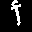

A.7 Menampilkan Pairplot

In [136]:
df_sample = df.sample(frac=0.2, random_state=42)

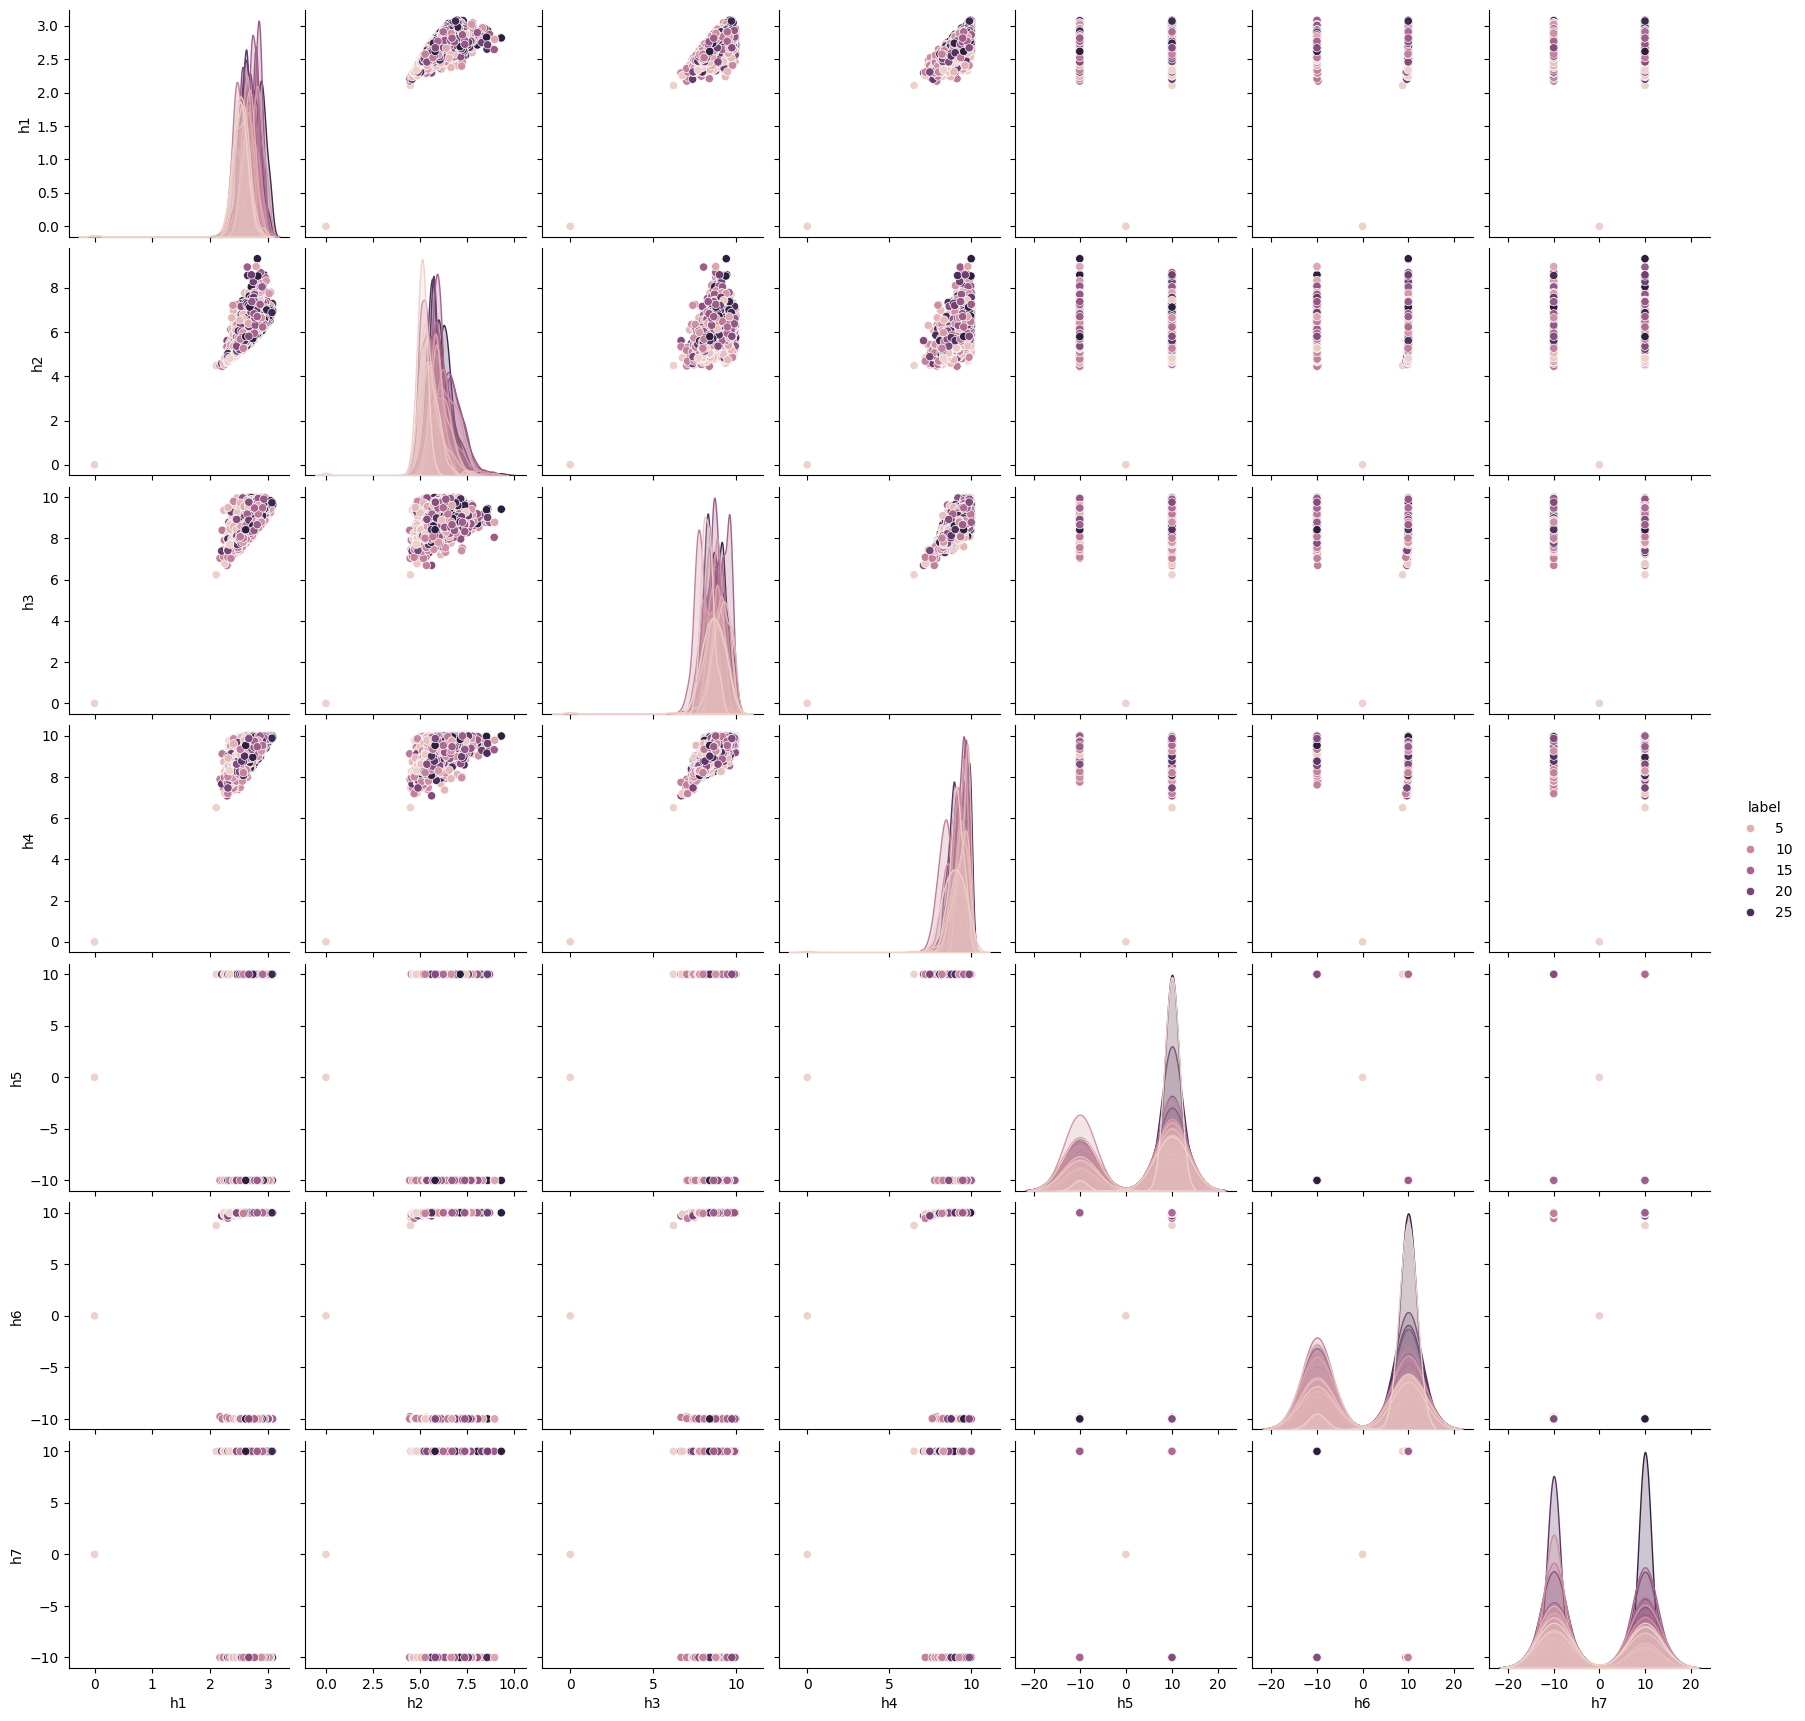

In [137]:
sns.pairplot(df_sample, hue='label')

**Insight:**

1. Terdapat data dengan nilai tidak wajar dengan nilai di setiap fitur 0, menunjukan ada hasil ekstraksi gambar yang tidak memiliki huruf didalmnya
2. label 1-4 (alif, ba, ta, tsa) yang berwarna cerah cenderung memiliki karakteristik dasar bentuk dengan nilai rendah (bentuknya sederhana) 


A.8 Menampilkan Boxplot Untuk Menampilkan Sebaran Outlier

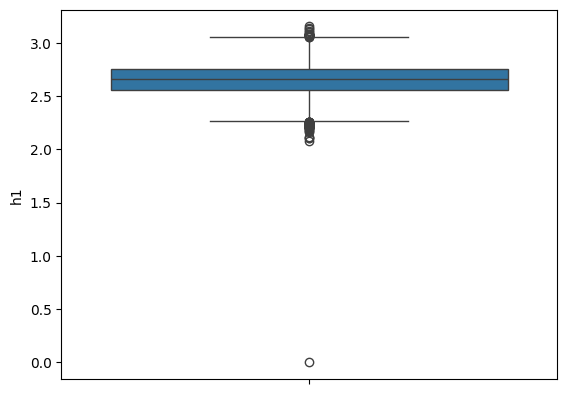

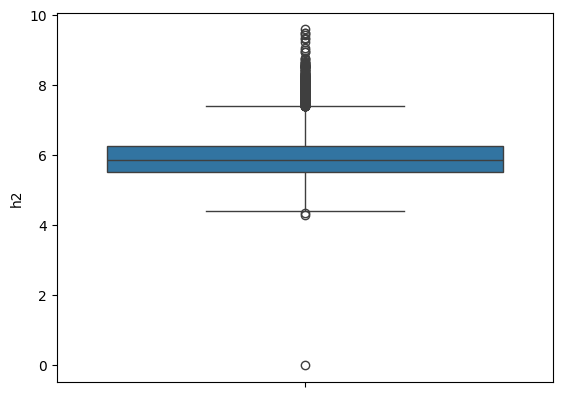

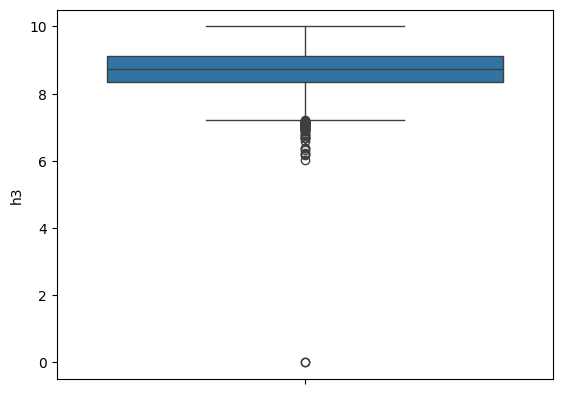

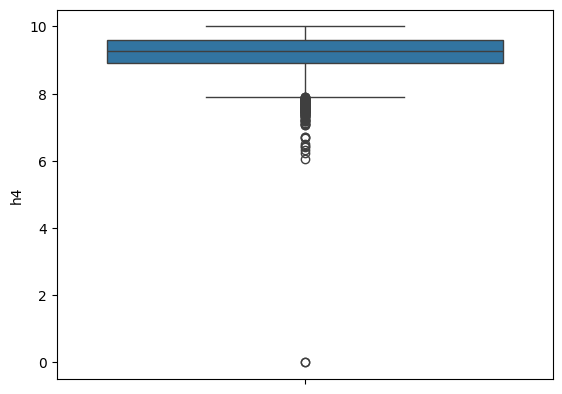

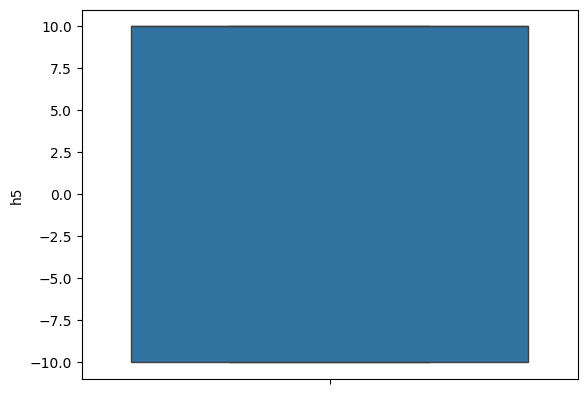

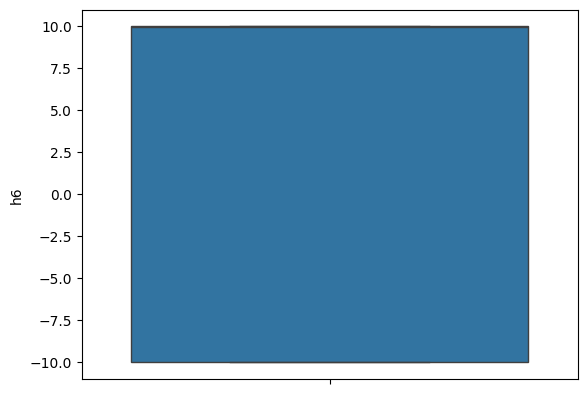

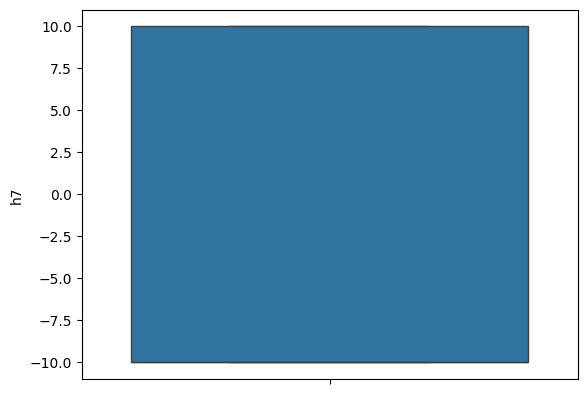

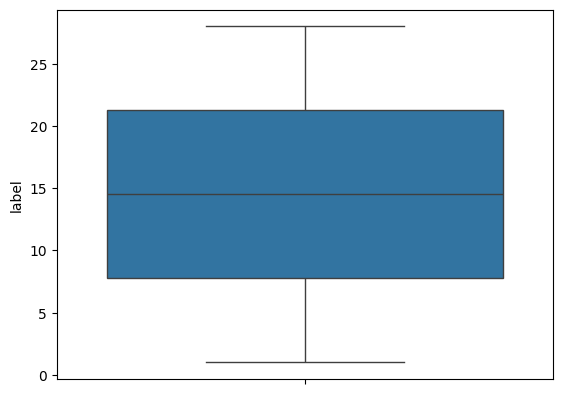

In [138]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

Insight : Untuk hasil boxplot ada beberapa nilai yang dianggap outlier, yaitu di kolom h1-h4

A.9 Menampilkan Nilai Outlier

In [139]:
df[df['h1'] == 0]

,h1,h2,h3,h4,h5,h6,h7,label
6050,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [140]:
df[df['h4'] == df['h4'].min()]

,h1,h2,h3,h4,h5,h6,h7,label
6050,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1
6568,2.951695,6.037605,0.0,0.0,0.0,0.0,0.0,10


Penanganan : Nilai Anomali diatas akan ditangani pada tahap data preprocessing dengan menghapusnya

Alasan : karena jika diisi dengan nilai rata-rata atau median maka akan menghasilkan data yang tidak masuk akal karena dataset hasil ekstraksi gambar

A.10 Menampilkan Histogram Untuk Melihat Distribusi Data

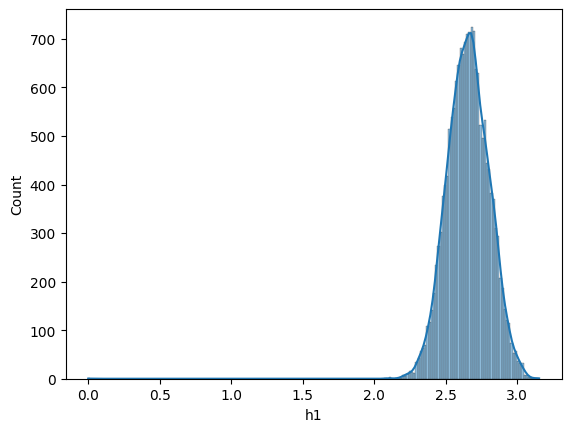

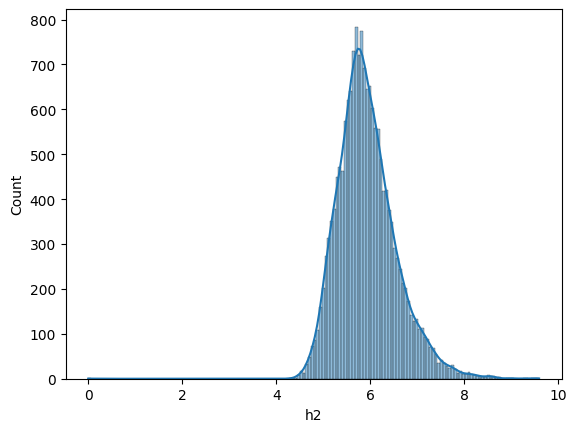

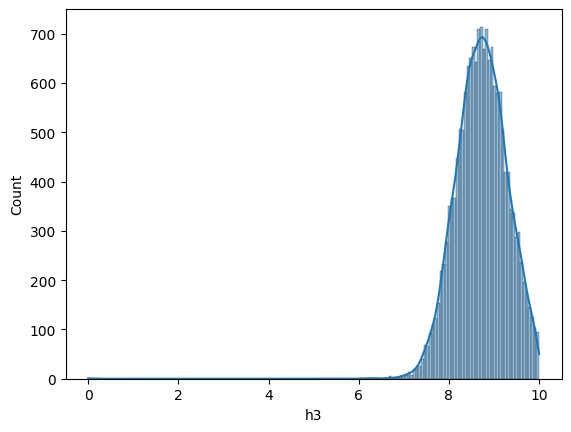

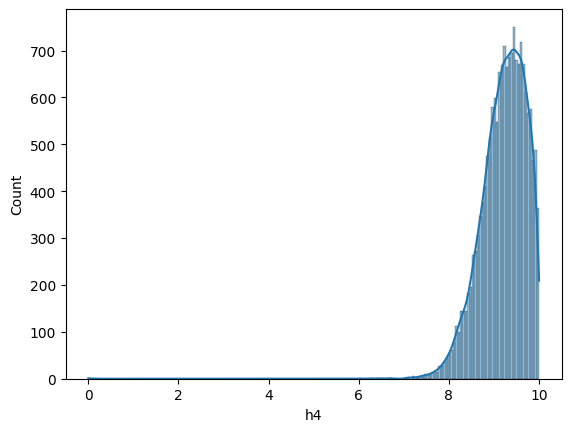

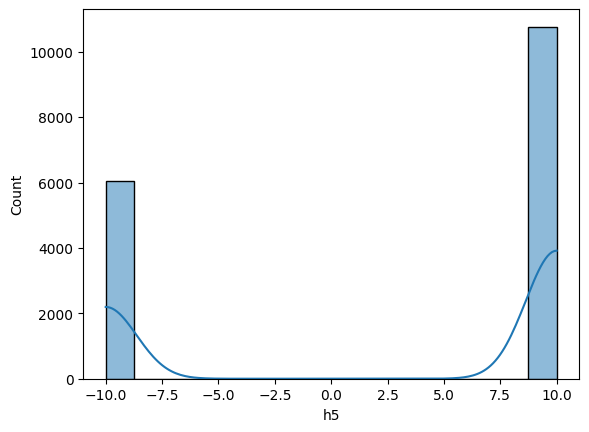

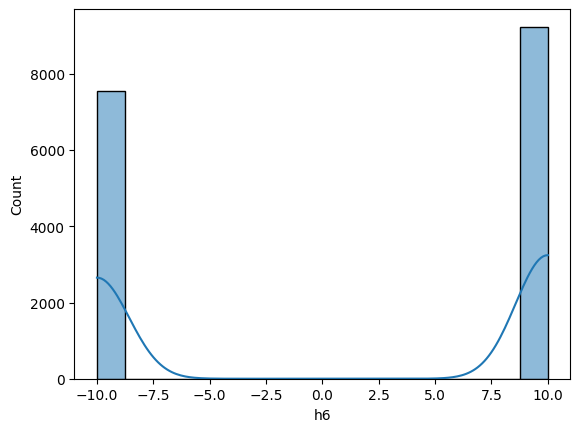

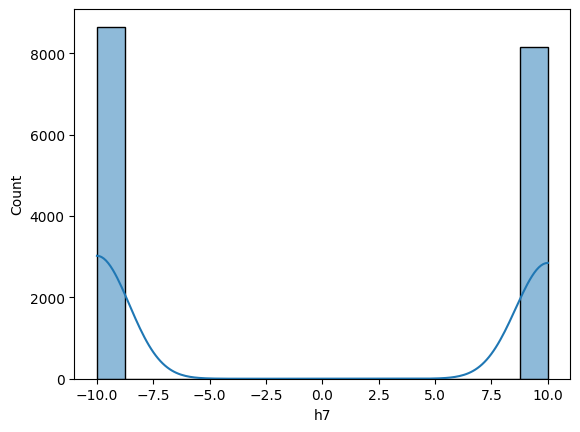

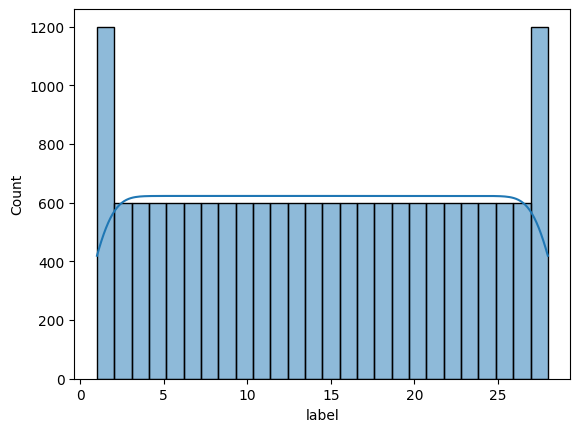

In [141]:
for i in df.columns:
    sns.histplot(df[i], kde=True)
    plt.show()

Untuk Insight dari histogram diatas:

- Kolom H1-4 memiliki distribusi yang miring ke kanan (diantara 7-10), artinya (khususnya di h3) hampir semua huruf hijaiyah memiliki bentuk yang tidak simetris
- untuk kolom H5-H7 memiliki distribusi yang berkumpul di 2 titik yaitu di -10 dan 10, yang artinya huruf2 hijaiyah memiliki 2 kemungkinan salah satunya apakah suatu huruf tersebut memiliki pola piksel yang lebih kompleks atau tidak

A.11 Menampilkan Distribusi Kolom Label

C:\Users\chiko\AppData\Local\Temp\ipykernel_29224\2208255160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='label', palette='pastel')


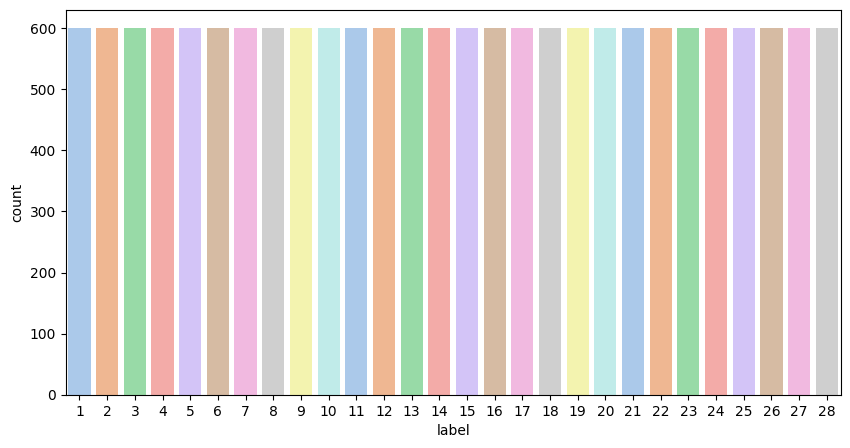

In [142]:
plt.figure(figsize=(10,5))
sns.countplot(df, x='label', palette='pastel')
plt.show()

Untuk hasil countplot diatas, menunjukan bahwa jumlah setiap data setiap huruf memiliki jumlah yang sama/setara. Namun kami perlu memastikan kembali dengan menampilkan nilai satuan

Memastikan Kembali distribusi apakah benar2 setara

In [143]:
values, count = np.unique(df['label'], return_counts=True)
print(values)
print(count)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28]
[600 600 600 600 600 600 600 600 600 600 600 600 600 600 600 600 600 600
 600 600 600 600 600 600 600 600 600 600]


Untuk hasilnya, kolom label memiliki distribusi yang setara

A.12 Menampilkan Matrix Korelasi Untuk Menampilkan Hubungan Antar Data

<Axes: >

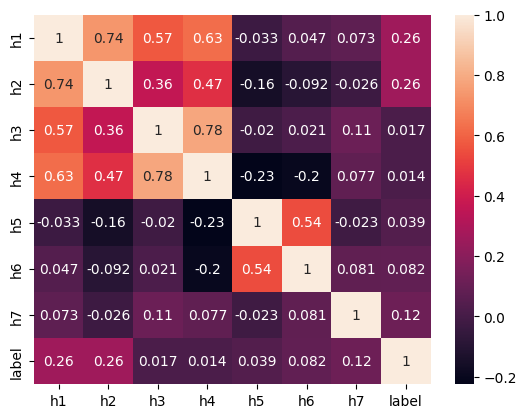

In [144]:
sns.heatmap(df.corr(), annot=True)

Hasil matrix korelasi diatas menunjukkan:

- Kolom h1 dan h2 memiliki hubungan yang menjelaskan informasi yang mirip, dengan angka korelasi (0.74)
- Label memiliki hubungan tidak kuat dengan fitur h1 dan h2 di angka (0.26)
- Untuk label dengan kolom h3-h7 hampir tidak memiliki hubungan, bukan berarti tidak memiliki informasi yang penting

Mengingat kembali karena kami menggunakan algoritma decision tree yang dapat menentukan fitur yang paling berpengaruh, maka kami tetap menggunakan seluruh fitur.

# B. Data Preprocessing

B.1 Menangani nilai duplikat

In [3]:
df = df.drop_duplicates()

B.2 Menampilkan Kembali Nilai Duplikat

In [4]:
df.duplicated().sum()

np.int64(0)

B.3 Menangani nilai anomali/outlier

In [5]:
df.drop(index=[6050, 6568], inplace=True)

Menampilkan Hasil penanganan anomali

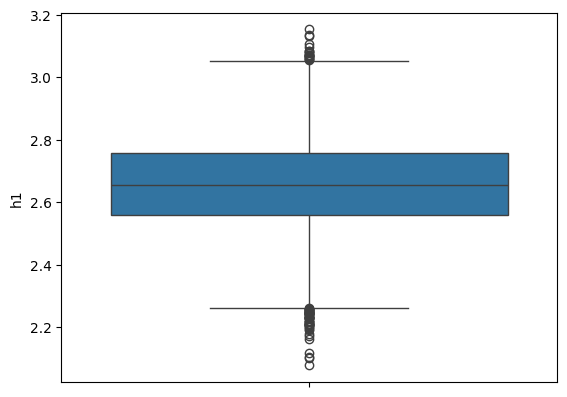

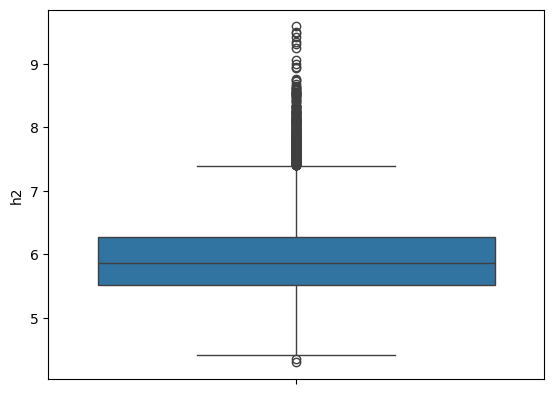

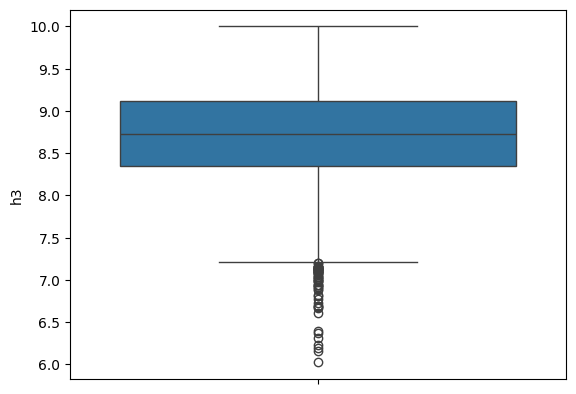

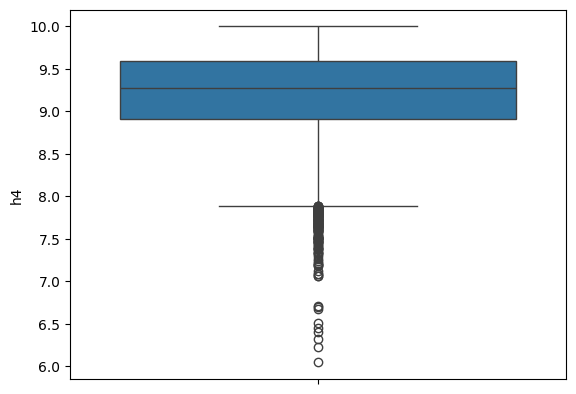

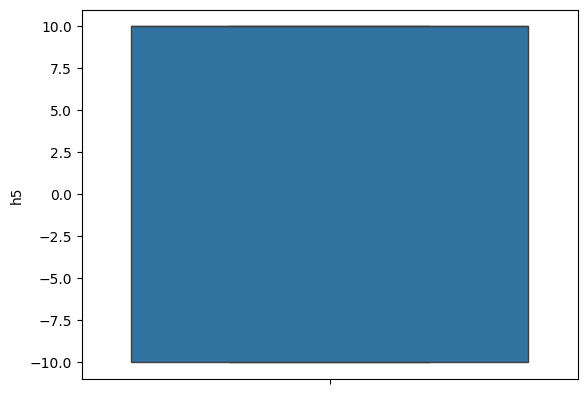

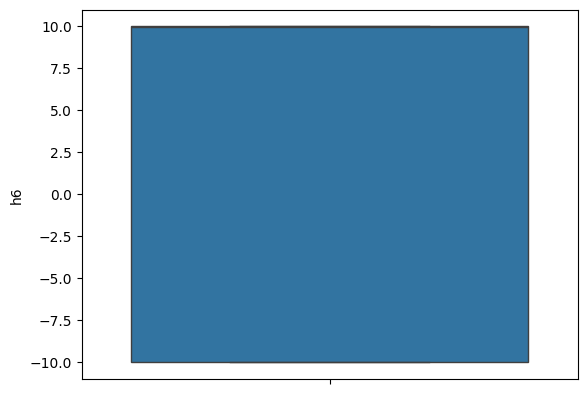

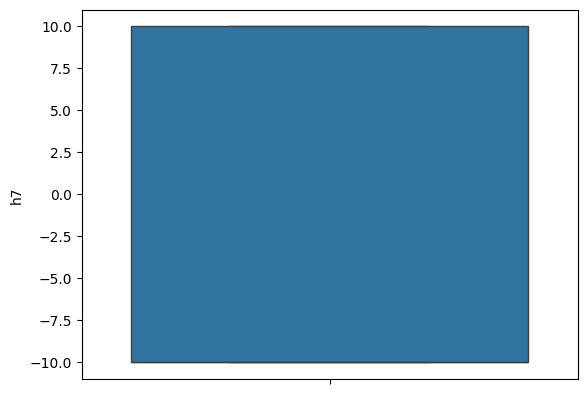

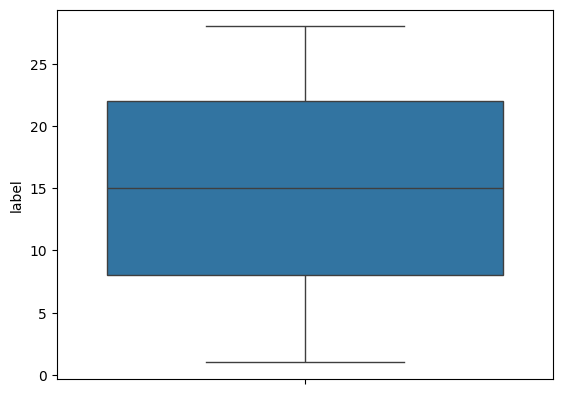

In [148]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

B.4 Split data untuk melatih dan test model

In [6]:
def stratified_split(df, kolom_label):
    daftar_train = []
    daftar_test = []
    labels = df[kolom_label].unique()
    for label in labels:
        label_train = df[df[kolom_label] == label].sample(frac=0.8, random_state=42, replace=False)
        label_test = df[df[kolom_label] == label].drop(label_train.index)

        daftar_train.append(label_train)
        daftar_test.append(label_test)
    
    daftar_train = pd.concat(daftar_train)
    daftar_test = pd.concat(daftar_test)

    x_tr = daftar_train.iloc[:,:-1]
    x_te = daftar_test.iloc[:,:-1]

    y_tr = daftar_train[kolom_label]
    y_te = daftar_test[kolom_label]

    return x_tr.values, x_te.values, y_tr.values, y_te.values

Kami menggunakan metode stratified split agar perbandingan jumlah label di data train dan data test setara. Untuk setiap label akan di split menjadi train sebesar 80% dari total data label tersebut, sisanya akan menjadi test.

Alasan:
 Kami memilih rasio proporsi split (80:20), karena jumlah data cukup yaitu tidak terlalu sedikit maupun terlalu banyak

B.5 Penerapan Function Stratified Split

In [7]:
x_tr, x_te, y_tr, y_te = stratified_split(df, kolom_label='label')

B.6 Menampilkan Dimensional Data Setelah Split

In [8]:
print(x_tr.shape)
print(y_tr.shape)
print(x_te.shape)
print(y_te.shape)

(13437, 7)
(13437,)
(3360, 7)
(3360,)


Untuk data setelah split, hasilnya:

- Data Train ada di 13437 baris
- Data test ada di 3360 baris

# C. Pemodelan

### Algoritma : Desicion Tree CART (Classification and Regression Tree)
Alasan: Desicion tree CART sebenarnya sudah cukup mampu memisahkan label dengan jumlah banyak untuk dataset dengan ukuran yang tidak terlalu besar seperti dataset ini. Jika menggunakan jenis algoritma desicion tree yang lain untuk label lebih dari 2 cabang akan terlalu kompleks.

C.1 Membuat class Decision Tree

In [9]:
class DecisionTree:
    # max_depth = batas kedalaman pohon untuk mencegah overfitting
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    # Mengambil label yang paling sering muncul
    def most_common_value(self, arr):
        unique, counts = np.unique(arr, return_counts=True)
        return unique[np.argmax(counts)]

    # menghitung Gini Impurity suatu node (seberapa campur isi node)
    def gini_impurity(self, y): 
        unique, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)      # probabilitas tiap kelas
        return 1 - np.sum(probs**2)   # rumus gini

    #Menghitung pengurangan impurity setelah split untuk menentukan split terbaik
    def gini_gain(self, parent, left, right):
        # impurity sebelum split
        parent_gini = self.gini_impurity(parent)

        # impurity di cabang kiri kanan
        left_gini = self.gini_impurity(left)
        right_gini = self.gini_impurity(right)

        # proporsi data di cabang kiri kanan
        left_weight = len(left) / len(parent)
        right_weight = len(right) / len(parent)

        # Pengurangan impurity
        return parent_gini - (left_weight * left_gini + right_weight * right_gini)

    # Fungsi rekursif untuk membangun tree
    def build_tree(self, x, y, current_depth):

        # Kondisi berhenti ketka sudah mencapai depth maksimum atau semua label dalam node sudah sama
        if current_depth >= self.max_depth or len(np.unique(y)) == 1:
            return self.most_common_value(y)

        # variabel untuk menyimpan split terbaik  
        best_feature = None
        best_split = None
        best_gain = -1

        # coba untuk semua fitur
        for feature in range(x.shape[1]):
            # ambil semua nilai unik pada fitur tersebut
            unique_values = np.unique(x[:, feature])

            #coba semua nilai unik sbg batas split
            for value in unique_values:
                # data <= split masuk cabang kiri
                left_mask = x[:, feature] <= value
                # data > split masuk cabang kanan
                right_mask = x[:, feature] > value

                # Skip jika salah satu cabang kosong
                if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                    continue

                # Hitung pengurngan impurity
                gain = self.gini_gain(y, y[left_mask], y[right_mask])

                # simpan jika lebih baik dari sebelumnya  
                if gain > best_gain:
                    best_feature = feature
                    best_split = value
                    best_gain = gain

        # jika tidak ditemukan split yang lebih baik
        # node dijadikan leaf
        if best_feature is None:
            return self.most_common_value(y)

        # pisahkan data berdasarkan split terbaik
        left_mask = x[:, best_feature] <= best_split
        right_mask = x[:, best_feature] > best_split

        # bangun cabang kiri dan kanan secara rekursif
        return {
            'feature': best_feature,
            'split': best_split,
            'left': self.build_tree(x[left_mask], y[left_mask], current_depth + 1),
            'right': self.build_tree(x[right_mask], y[right_mask], current_depth + 1)
        }

    # fungsi untuk melatih model
    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)

    # prediksi satu sample
    def predict_sample(self, tree, sample):

        # jika node bukan dictionary berarti leaf
        if not isinstance(tree, dict):
            return tree

        feature_index = tree['feature']
        split_value = tree['split']

        # pilih cabang sesuai kondisi split
        if sample[feature_index] <= split_value:
            return self.predict_sample(tree['left'], sample)
        else:
            return self.predict_sample(tree['right'], sample)

    # prediksi banyak data
    def predict(self, X):
        predictions = []

        for sample in X:
            pred = self.predict_sample(self.tree, sample)
            predictions.append(pred)
        return np.array(predictions)

C.2 Melakukan grid search untuk mencari kedalaman yang optimal

In [165]:
def grid_search(depth_list, x_tr, y_tr, x_te, y_te):
    akurasi_tr = []
    akurasi_te = []
    # Coba setiap depth yang ada
    for depth in depth_list:
        model = DecisionTree(max_depth=depth) # buat model dengan depth saat ini
        model.fit(x_tr, y_tr) # melatih/membangun pohon
        y_tr_pred = model.predict(x_tr) # Prediksi label 
        y_te_pred = model.predict(x_te) # Prediksi label 
        akurasi_tr.append(np.mean(y_tr_pred == y_tr)) # menyimpan akurasi depth saat ini
        akurasi_te.append(np.mean(y_te_pred == y_te)) # menyimpan akurasi depth saat ini

    return akurasi_tr, akurasi_te

In [168]:
akurasi_train, akurasi_test = grid_search([2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17], x_tr, y_tr, x_te, y_te)
print(akurasi_train)
print(akurasi_test)

[np.float64(0.10612487906526755), np.float64(0.15122423159931533), np.float64(0.18672322691076879), np.float64(0.2290689886135298), np.float64(0.26099575798169233), np.float64(0.3012577212175337), np.float64(0.34591054550867006), np.float64(0.39956835603185237), np.float64(0.4584356627223339), np.float64(0.5231078365706631), np.float64(0.599017637865595), np.float64(0.679988092580189), np.float64(0.7554513656322096), np.float64(0.8250353501525638), np.float64(0.879214110292476), np.float64(0.9228250353501526)]
[np.float64(0.10386904761904762), np.float64(0.1351190476190476), np.float64(0.1636904761904762), np.float64(0.20535714285714285), np.float64(0.22470238095238096), np.float64(0.25148809523809523), np.float64(0.2663690476190476), np.float64(0.2839285714285714), np.float64(0.28422619047619047), np.float64(0.28422619047619047), np.float64(0.28273809523809523), np.float64(0.27529761904761907), np.float64(0.274702380952381), np.float64(0.27380952380952384), np.float64(0.27053571428571

C.3 Menampilkan hasil grid search (perbandingan akurasi train dan test)

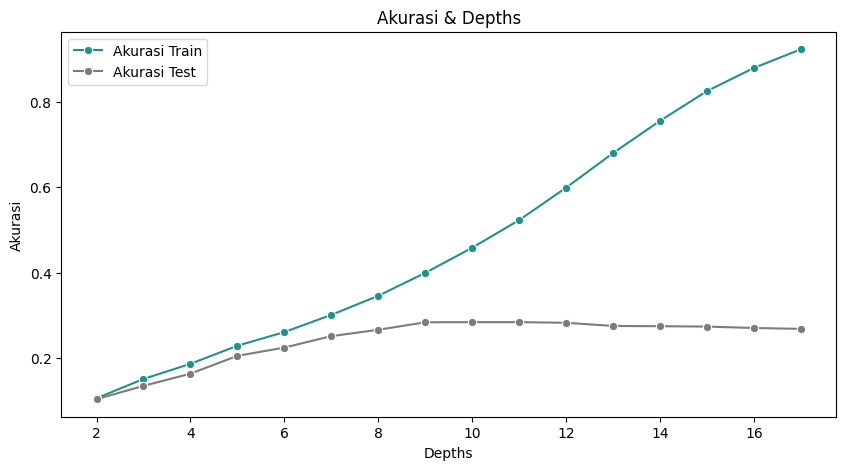

In [200]:
index = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
akurasi_train_df = pd.DataFrame(akurasi_train, columns=['Akurasi Train'], index=index)
akurasi_test_df = pd.DataFrame(akurasi_test, columns=['Akurasi Test'], index=index)

plt.figure(figsize=[10,5])
sns.lineplot(data=akurasi_train_df, markers='o', palette='viridis')
sns.lineplot(data=akurasi_test_df, markers='o', palette='cividis')
plt.legend()
plt.title('Akurasi & Depths')
plt.xlabel('Depths')
plt.ylabel('Akurasi')
plt.show()

Insight:

Gap akurasi mulai renggang/tinggi ketika jumlah kedalaman melebihi jumlah fitur (>7), menunjukan semakin dalam kedalaman (melebihi jumlah fitur), maka akan semakin overfit model, dan test nya akan tidak memiliki peningkatan sama sekali

Kami memutuskan menggunakan k 6 karena gap akurasi yang tidak jauh

C.4 Membangun pohon

In [10]:
model = DecisionTree(6)

In [11]:
model.fit(x_tr,y_tr)

In [12]:
def plot_tree(node, feature_names, x=0.5, y=1, dx=0.25, dy=0.08, ax=None, depth=0, max_depth=4):

    if ax is None:
        fig, ax = plt.subplots(figsize=(20,10))
        ax.axis("off")

    if not isinstance(node, dict):
        ax.text(
            x, y,
            f"Class: {node}",
            ha="center",
            bbox=dict(boxstyle="round", fc="#90EE90")
        )
        return ax

    if depth >= max_depth:
        ax.text(
            x, y,
            "...",
            ha="center",
            bbox=dict(boxstyle="round", fc="#f4a261")
        )
        return ax

    feature = feature_names[node["feature"]]
    split = node["split"]

    label = f"{feature} ≤ {split:.2f}"

    ax.text(
        x, y,
        label,
        ha="center",
        bbox=dict(boxstyle="round", fc="#add8e6")
    )

    ax.plot([x, x-dx], [y, y-dy], 'k-')
    plot_tree(node["left"], feature_names, x-dx, y-dy, dx/2, dy, ax, depth+1, max_depth)

    ax.plot([x, x+dx], [y, y-dy], 'k-')
    plot_tree(node["right"], feature_names, x+dx, y-dy, dx/2, dy, ax, depth+1, max_depth)

    return ax

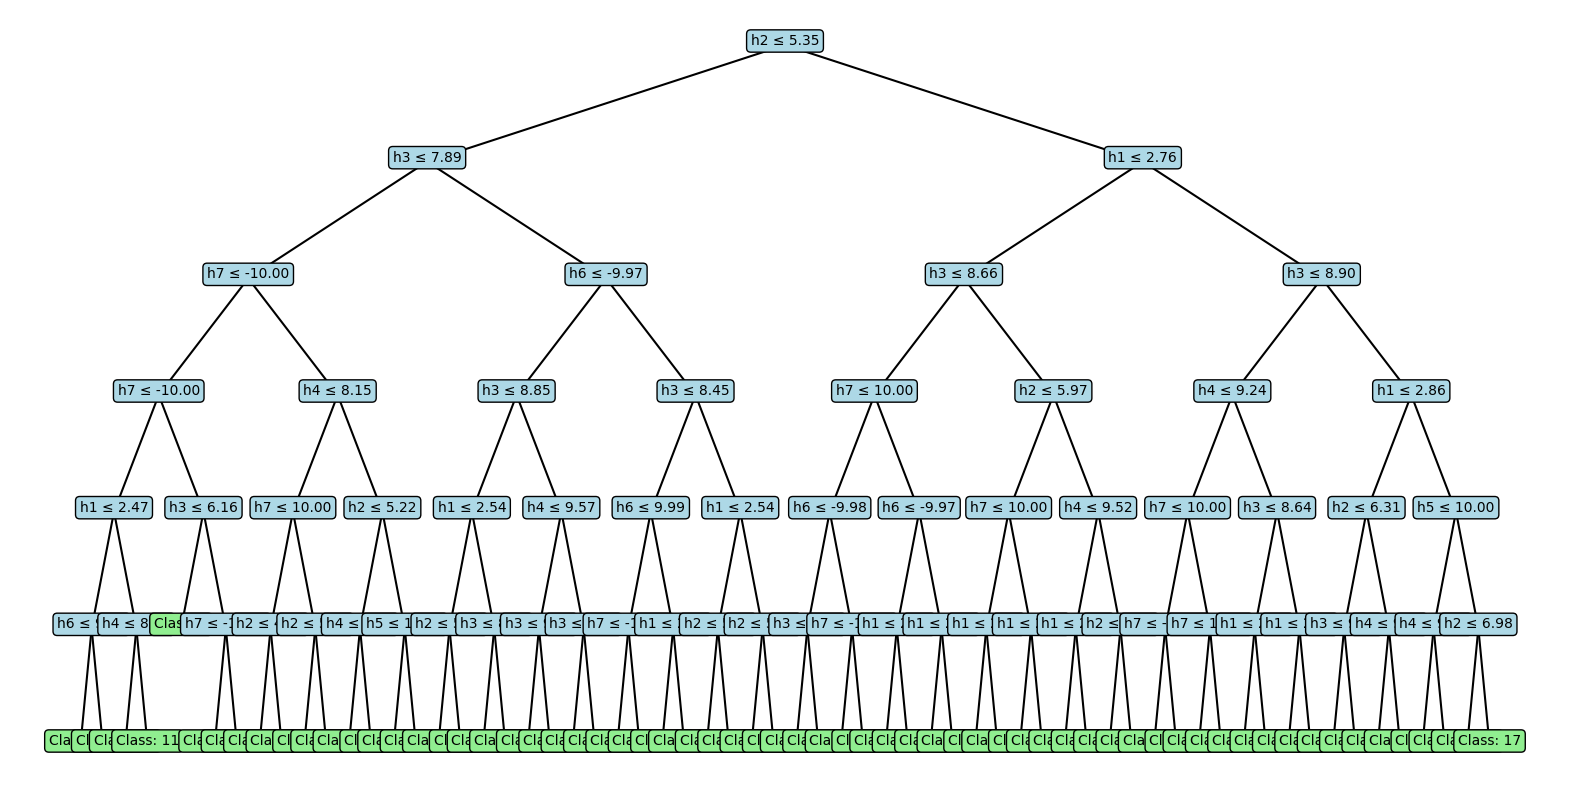

In [13]:
fitur = df.iloc[:,:-1].columns
plot_tree(model.tree, fitur, max_depth=6)
plt.show()

In [22]:
y_tr_pred = model.predict(x_tr)
y_te_pred = model.predict(x_te)

# D. Evaluasi dan GUI

D.1 Fungsi confussion matrix dan metrik evaluasi (presicion, recall, akurasi)

In [23]:
huruf = ["alif","ba","ta","tsa","jim","ha","kho","dal","dzal","ro'","zai'","sin","syin","shot","dhot","tho'","dho'","'ain","ghoin","fa'","qof","kaf","lam","mim","nun","Ha'","wau","ya'"]
def evaluasi_model(y,y_pred):
    lbl = np.unique(np.concatenate((y,y_pred), dtype=int),)
    cm = pd.DataFrame(np.zeros([len(lbl), len(lbl)]), columns=lbl, index=lbl, dtype=int)

    # buat confussion matrix
    for a, p in zip(y,y_pred):
        cm.loc[a,p] += 1 

    akurasi = np.mean(y == y_pred)
    print(f'AKURASI : {akurasi:.5f}')
    print('=' * 40)


    # hitung presisi dan recall setiap huruf
    for l in lbl:
        tp = cm.loc[l,l]
        fp = cm[l].sum() - tp
        fn = cm.loc[l].sum() - tp

        presisi = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        
        print(f'Huruf {huruf[l-1]}')
        print(f'presisi : {presisi:.5f}')
        print(f'recall  : {recall:.5f}')
        print('-' * 40)

    plt.figure(figsize=[20,20])
    sns.heatmap(cm, annot=True,fmt='d', xticklabels=huruf, yticklabels=huruf, cmap='BuGn')
    plt.xlabel('Predict')
    plt.ylabel('Actual')
    plt.show()

D.2 Evaluasi model jika memprediksi data baru/test


AKURASI : 0.26100
Huruf alif
presisi : 0.41563
recall  : 0.76618
----------------------------------------
Huruf ba
presisi : 0.24916
recall  : 0.15417
----------------------------------------
Huruf ta
presisi : 0.14378
recall  : 0.51042
----------------------------------------
Huruf tsa
presisi : 0.71429
recall  : 0.01042
----------------------------------------
Huruf jim
presisi : 0.00000
recall  : 0.00000
----------------------------------------
Huruf ha
presisi : 0.00000
recall  : 0.00000
----------------------------------------
Huruf kho
presisi : 0.00000
recall  : 0.00000
----------------------------------------
Huruf dal
presisi : 0.45205
recall  : 0.20668
----------------------------------------
Huruf dzal
presisi : 0.39353
recall  : 0.48125
----------------------------------------
Huruf ro'
presisi : 0.29777
recall  : 0.53027
----------------------------------------
Huruf zai'
presisi : 0.70934
recall  : 0.42708
----------------------------------------
Huruf sin
presisi : 0.000

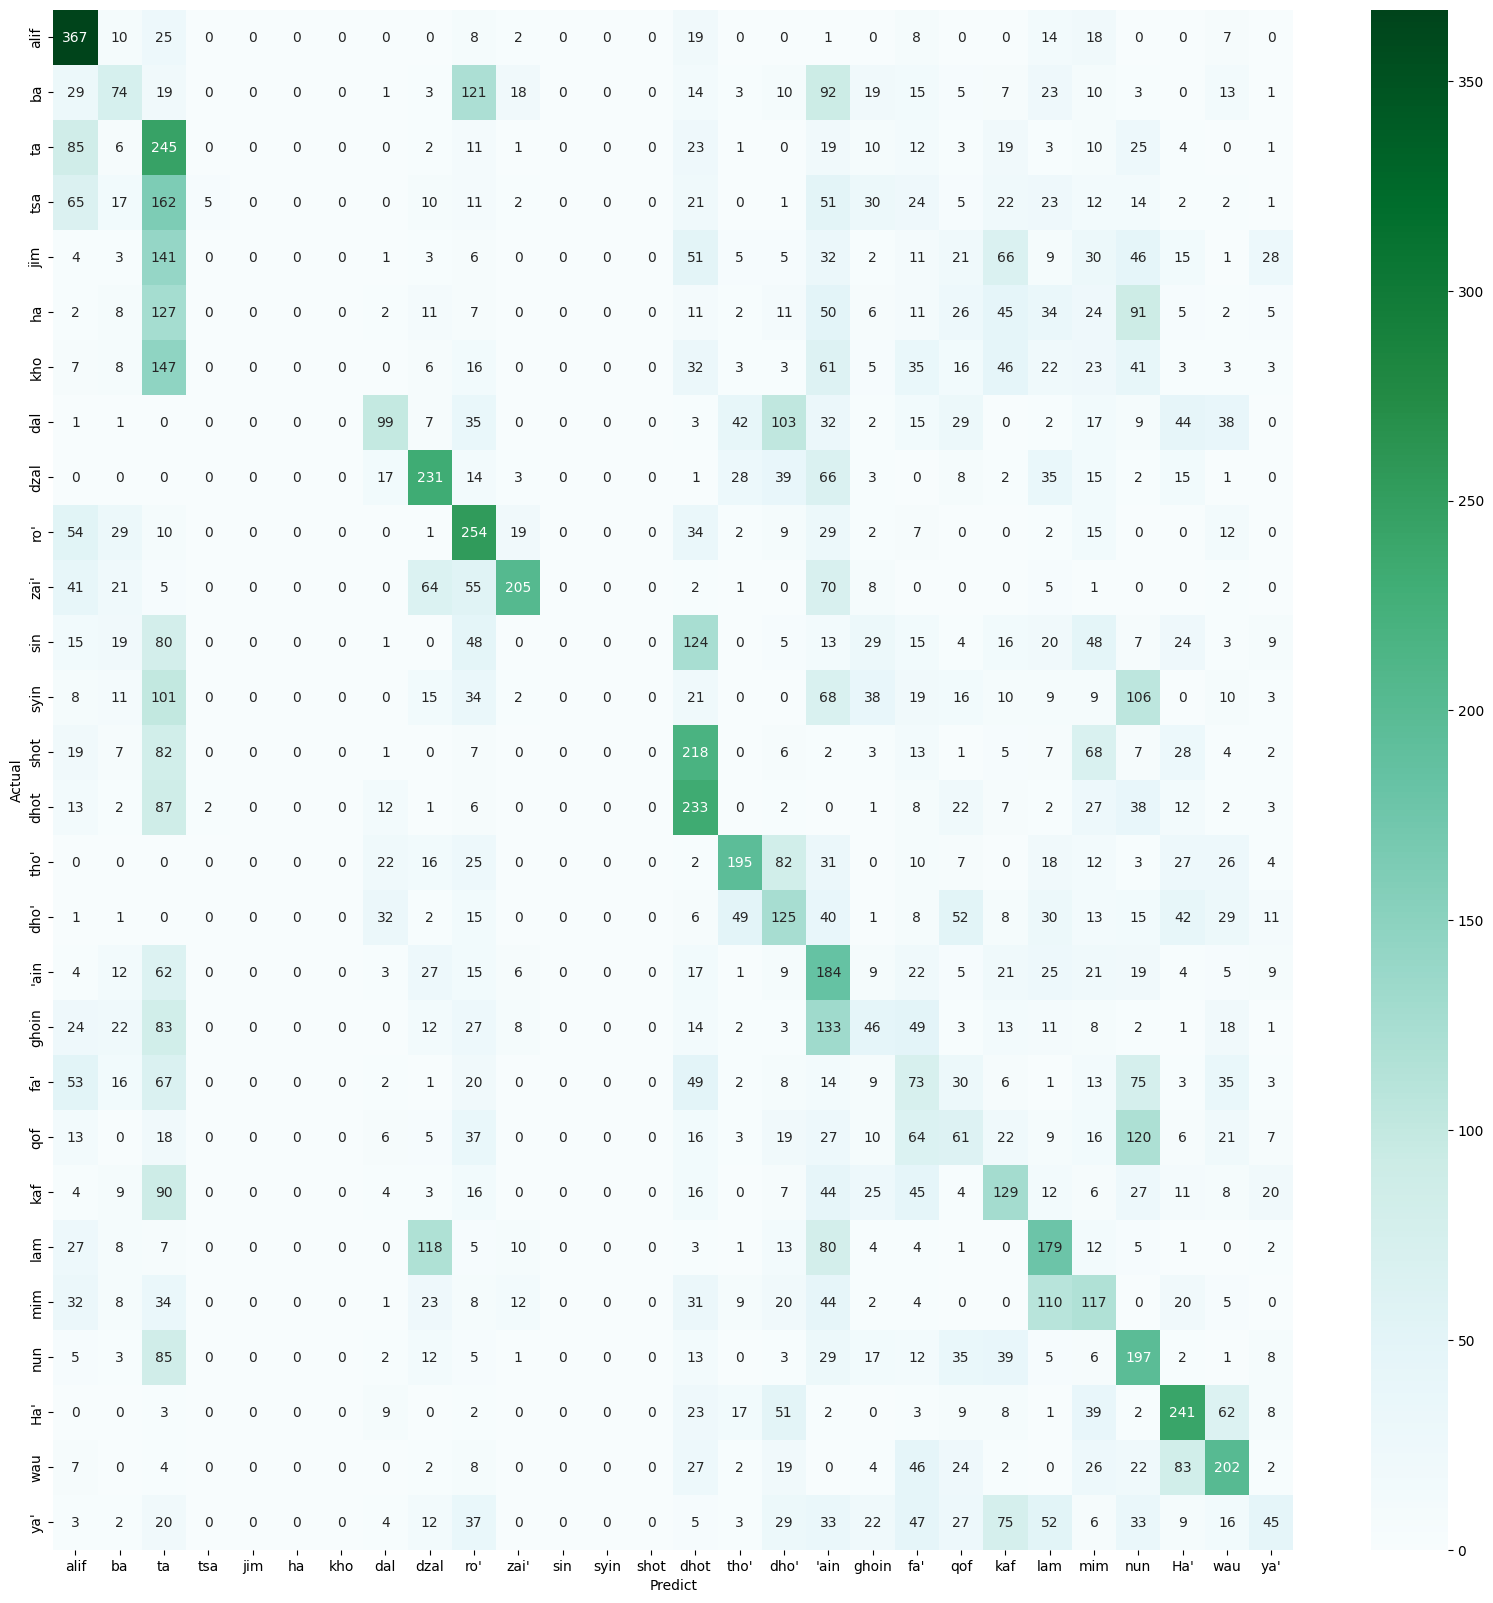

In [24]:
evaluasi_model(y_tr, y_tr_pred)

D.3 Evaluasi model jika memprediksi data baru/test

AKURASI : 0.22470
Huruf alif
presisi : 0.30916
recall  : 0.67500
----------------------------------------
Huruf ba
presisi : 0.19000
recall  : 0.15833
----------------------------------------
Huruf ta
presisi : 0.13902
recall  : 0.47500
----------------------------------------
Huruf tsa
presisi : 0.33333
recall  : 0.00833
----------------------------------------
Huruf jim
presisi : 0.00000
recall  : 0.00000
----------------------------------------
Huruf ha
presisi : 0.00000
recall  : 0.00000
----------------------------------------
Huruf kho
presisi : 0.00000
recall  : 0.00000
----------------------------------------
Huruf dal
presisi : 0.36667
recall  : 0.18333
----------------------------------------
Huruf dzal
presisi : 0.32500
recall  : 0.43333
----------------------------------------
Huruf ro'
presisi : 0.25943
recall  : 0.45833
----------------------------------------
Huruf zai'
presisi : 0.62821
recall  : 0.40833
----------------------------------------
Huruf sin
presisi : 0.000

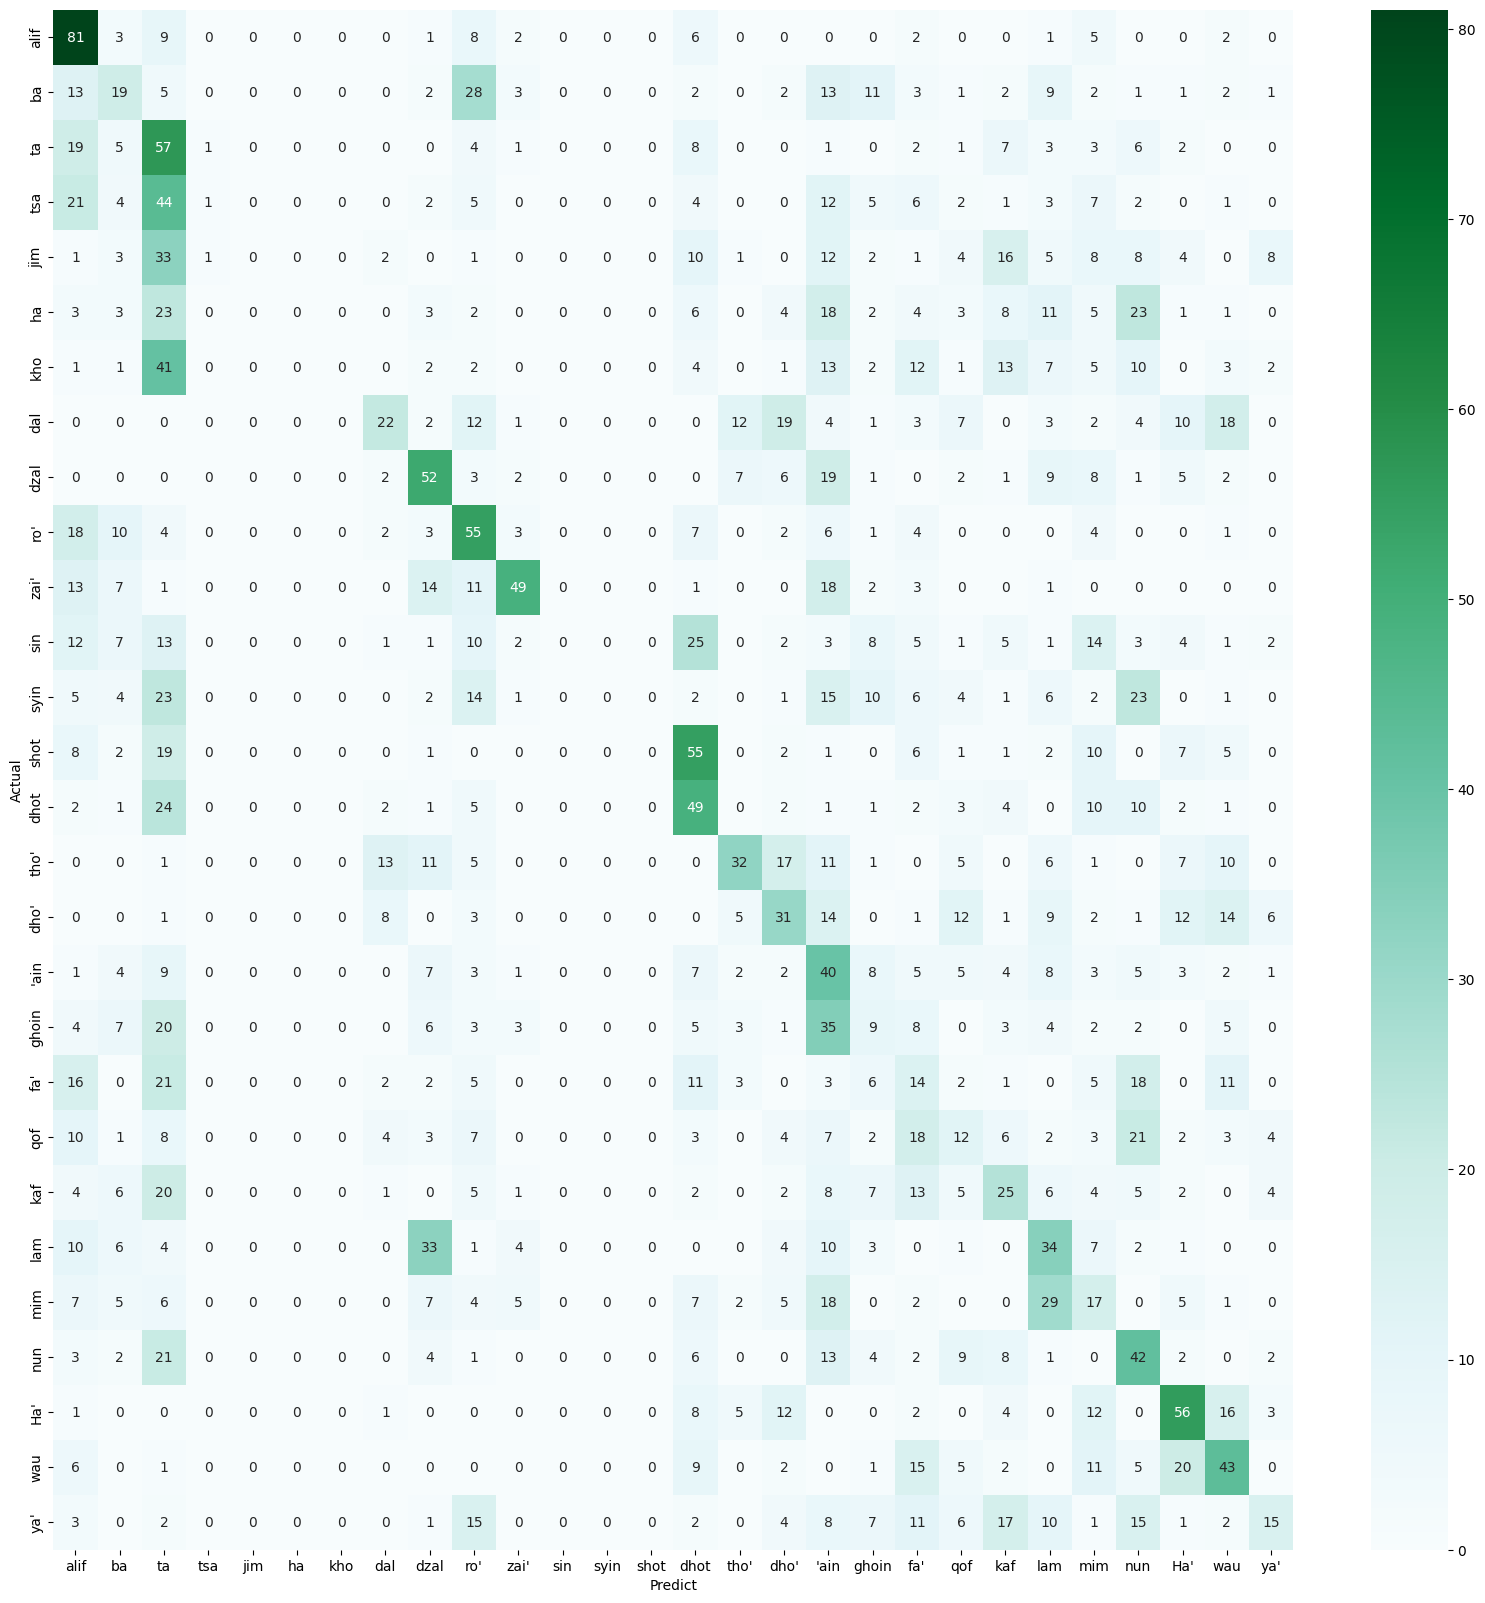

In [25]:
evaluasi_model(y_te, y_te_pred)


### Kesimpulan

**Performa**:
- Model kami tidak overfit maupun underfit
- Model kami yang dilatih dengan dataset yang diberikan belum mampu memprediksi secara benar secara keseluruhan semua jenis huruf yang ada, namun model masih mampu untuk membedakan dan memprediksi dengan baik beberapa huruf.

**Kemungkinan Penyebab:**
- Adanya huruf arab pada dataset yang memiliki bentuk serupa dan kurang jelas
- Fitur hasil ekstraksi yang disediakan kurang menjelaskan informasi gambar dengan baik
- Model yang dipakai kurang sesuai

**Kemungkinan Optimasi Kedepanya:**
- Mencoba algoritma decision tree lain selain CART

D. 4 GUI

In [26]:
def submit():
    try:
        input = str(entry_input.get())
        x_baru = (input.split(sep=','))
        x_baru = [[float(x) for x in x_baru]]
        print(x_baru)
        y_pred = model.predict(x_baru)
        
        for i in range(0,28):
            if y_pred[0] == i:
                y_pred = huruf[i-1]

        messagebox.showinfo('Hasil Prediksi',f'Hasil prediksi gambar tersebut adalah: {y_pred}')
            
    except ValueError:
        messagebox.showinfo('Value Error', 'Masukan data yang valid')

bg_color = "#0E192C"
input_color = "#233149"
fg_color = 'whitesmoke'
btn_color = "#0A6B56"
frame_color = "#8B1E1E"
font = ['Arial', 12]

window = Tk()
window.configure(bg=bg_color)
window.title('Prediksi Huruf Arab')
window.geometry('320x450')

lbl_judul = Label(window, text='Prediksi Huruf Arab', font=['Arial', 18, 'bold'], bg=bg_color, fg=fg_color)
lbl_judul.pack(pady=10, padx=10)

lbl_spasi = Label(window, bg=bg_color)
lbl_spasi.pack(pady=30)

lbl_input = Label(window, text='Masukan data hasil ekstraksi gambar', font=font, bg=bg_color, fg=fg_color)
lbl_input.pack(pady=10, padx=10)

entry_input = Entry(fg=fg_color, bg=input_color, relief=FLAT, width=43)
entry_input.pack(pady=10, padx=10)

lbl_spasi = Label(window, bg=bg_color)
lbl_spasi.pack(pady=10)


btn_submit = Button(window,text='Prediksi', fg=fg_color, bg=btn_color, relief=FLAT, font=['Arial', 12, 'bold'], width=13, command=submit)
btn_submit.pack(pady=10, padx=10)
  
container = Frame(window, bg=frame_color,)
container.pack(side='bottom', pady=10)

note = Label(container, text='Cukup masukan input satu baris data hasil ekstraksi.\nModel AI memiliki akurasi 22%', bg=frame_color, fg=fg_color)
note.pack(pady=5, padx=5)

window.mainloop()